In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Saving social_media_posts.csv to social_media_posts (1).csv
Dataset loaded successfully!
Shape: (250, 11)


,Post_ID,Date,Time,User,Content,Hashtags,Category,Likes,Comments,Shares,Expected_Sentiment
0,POST_028,2026-07-15,08:00:00,AIInsights,Sharing today's update and the latest observat...,#Python #CareerGrowth,Education,137,162,343,Neutral
1,POST_202,2026-07-15,08:30:00,TechNeha,Absolutely loved this update! The results are ...,#GenerativeAI #ArtificialIntelligence #AI,AI,1963,262,734,Positive
2,POST_220,2026-07-15,08:50:00,AnalyticsGuru,A new feature has been released for users to e...,#TechNews #Coding #Innovation #Technology,Technology,667,269,98,Neutral
3,POST_160,2026-07-15,10:30:00,MLExplorer,Great insights and an excellent learning exper...,#Entrepreneurship #Startups #Marketing #Business,Business,1563,253,278,Positive
4,POST_045,2026-07-15,11:00:00,DataNinja,So excited to share this wonderful milestone w...,#GenerativeAI #ArtificialIntelligence #AI,AI,2393,219,463,Positive


In [2]:
# Check dataset information
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove duplicate posts
df = df.drop_duplicates(subset="Post_ID")

# Convert engagement columns to numeric
engagement_columns = ["Likes", "Comments", "Shares"]

for col in engagement_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Create Total Engagement
df["Total_Engagement"] = (
    df["Likes"] +
    df["Comments"] +
    df["Shares"]
)

# Extract posting hour
df["Posting_Hour"] = pd.to_datetime(
    df["Time"],
    format="%H:%M:%S",
    errors="coerce"
).dt.hour

print("Data cleaned successfully!")

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Post_ID             250 non-null    object
 1   Date                250 non-null    object
 2   Time                250 non-null    object
 3   User                250 non-null    object
 4   Content             250 non-null    object
 5   Hashtags            250 non-null    object
 6   Category            250 non-null    object
 7   Likes               250 non-null    int64 
 8   Comments            250 non-null    int64 
 9   Shares              250 non-null    int64 
 10  Expected_Sentiment  250 non-null    object
dtypes: int64(3), object(8)
memory usage: 21.6+ KB
None

Missing Values:
Post_ID               0
Date                  0
Time                  0
User                  0
Content               0
Hashtags              0
Category              0
Likes                 0
Commen

,Post_ID,Date,Time,User,Content,Hashtags,Category,Likes,Comments,Shares,Expected_Sentiment,Total_Engagement,Posting_Hour
0,POST_028,2026-07-15,08:00:00,AIInsights,Sharing today's update and the latest observat...,#Python #CareerGrowth,Education,137,162,343,Neutral,642,8
1,POST_202,2026-07-15,08:30:00,TechNeha,Absolutely loved this update! The results are ...,#GenerativeAI #ArtificialIntelligence #AI,AI,1963,262,734,Positive,2959,8
2,POST_220,2026-07-15,08:50:00,AnalyticsGuru,A new feature has been released for users to e...,#TechNews #Coding #Innovation #Technology,Technology,667,269,98,Neutral,1034,8
3,POST_160,2026-07-15,10:30:00,MLExplorer,Great insights and an excellent learning exper...,#Entrepreneurship #Startups #Marketing #Business,Business,1563,253,278,Positive,2094,10
4,POST_045,2026-07-15,11:00:00,DataNinja,So excited to share this wonderful milestone w...,#GenerativeAI #ArtificialIntelligence #AI,AI,2393,219,463,Positive,3075,11


In [3]:
# Extract all hashtags
all_hashtags = []

for hashtags in df["Hashtags"].dropna():
    tags = re.findall(r"#\w+", str(hashtags))
    all_hashtags.extend([tag.lower() for tag in tags])

# Count hashtags
hashtag_counts = (
    pd.Series(all_hashtags)
    .value_counts()
    .reset_index()
)

hashtag_counts.columns = ["Hashtag", "Count"]

top_hashtags = hashtag_counts.head(10)

print("🔥 Top Trending Hashtags")
print(top_hashtags)

🔥 Top Trending Hashtags
                   Hashtag  Count
0                  #python     55
1                  #coding     42
2              #innovation     40
3              #technology     40
4  #artificialintelligence     38
5                      #ai     37
6               #analytics     37
7                #technews     36
8            #generativeai     36
9             #datascience     33


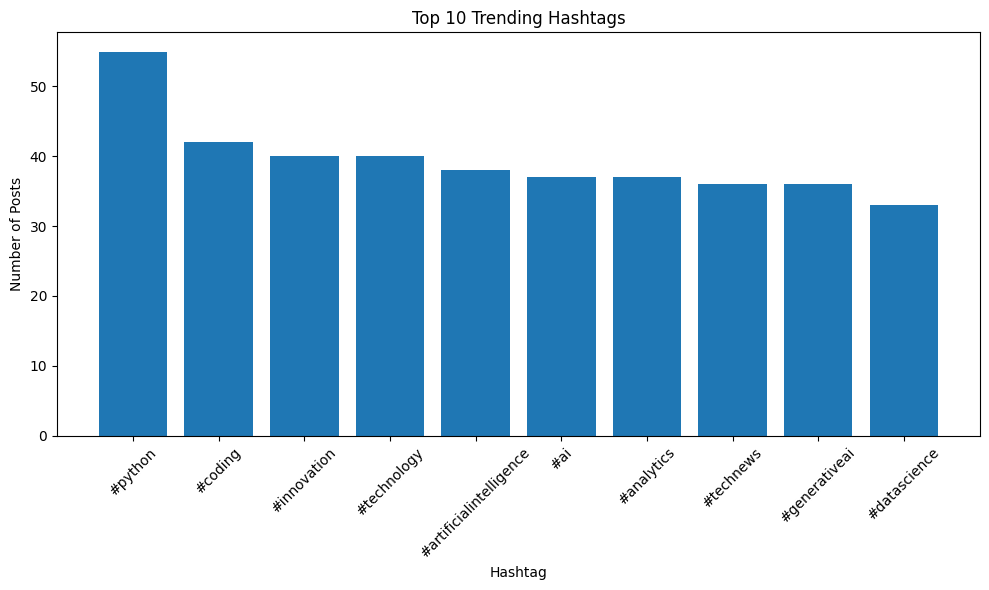

In [4]:
plt.figure(figsize=(10, 6))

plt.bar(
    top_hashtags["Hashtag"],
    top_hashtags["Count"]
)

plt.title("Top 10 Trending Hashtags")
plt.xlabel("Hashtag")
plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [5]:
active_users = (
    df["User"]
    .value_counts()
    .reset_index()
)

active_users.columns = ["User", "Posts"]

print("👥 Most Active Users")
print(active_users.head(10))

👥 Most Active Users
            User  Posts
0     AIInsights     30
1      DataNinja     24
2  DataWithAarav     23
3   CodeWithRiya     23
4     MLExplorer     22
5      PythonDev     21
6       ShreyaAI     20
7       TechNeha     20
8       DevVibes     19
9     CloudCoder     17


In [6]:
total_likes = df["Likes"].sum()
total_comments = df["Comments"].sum()
total_shares = df["Shares"].sum()
total_engagement = df["Total_Engagement"].sum()

average_engagement = df["Total_Engagement"].mean()

print("📊 ENGAGEMENT ANALYSIS")
print("-" * 35)

print(f"Total Likes: {total_likes:,}")
print(f"Total Comments: {total_comments:,}")
print(f"Total Shares: {total_shares:,}")
print(f"Total Engagement: {total_engagement:,}")
print(f"Average Engagement per Post: {average_engagement:,.2f}")

📊 ENGAGEMENT ANALYSIS
-----------------------------------
Total Likes: 347,013
Total Comments: 44,411
Total Shares: 68,265
Total Engagement: 459,689
Average Engagement per Post: 1,838.76


In [7]:
popular_posting_time = (
    df["Posting_Hour"]
    .value_counts()
    .sort_values(ascending=False)
)

most_popular_hour = popular_posting_time.index[0]

print("🕒 MOST POPULAR POSTING TIME")
print(
    f"{most_popular_hour:02d}:00 - "
    f"{(most_popular_hour + 1) % 24:02d}:00"
)

popular_posting_time.head(10)

🕒 MOST POPULAR POSTING TIME
22:00 - 23:00


,count
Posting_Hour,
22,25
14,25
12,19
10,19
23,17
15,16
20,14
8,14
11,14


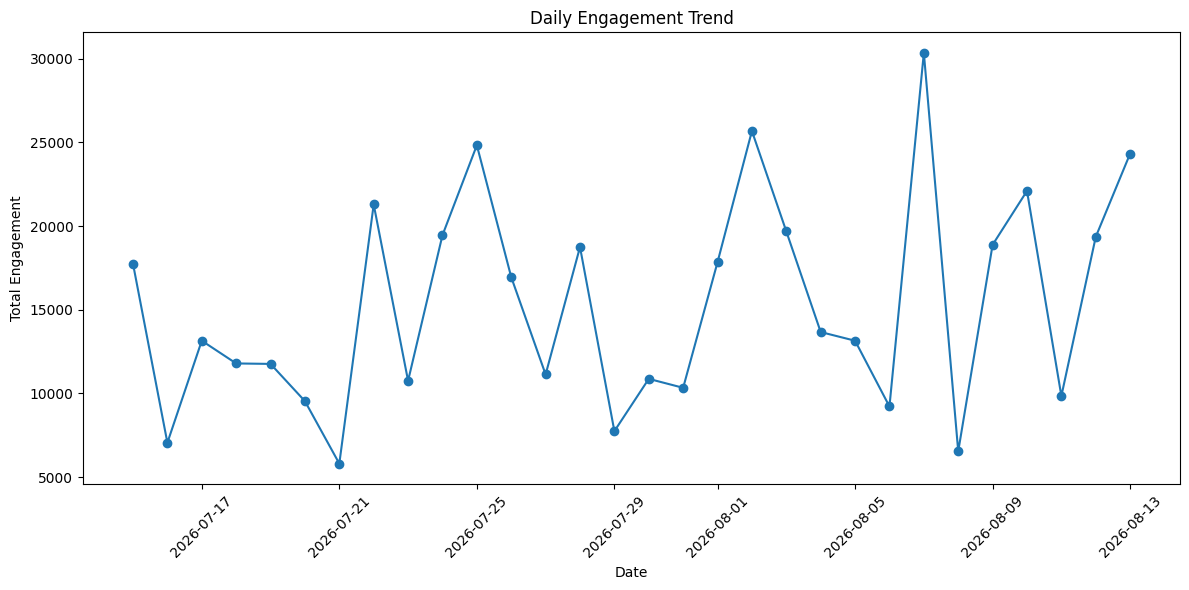

In [8]:
daily_engagement = (
    df.groupby("Date")["Total_Engagement"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

plt.plot(
    daily_engagement["Date"],
    daily_engagement["Total_Engagement"],
    marker="o"
)

plt.title("Daily Engagement Trend")
plt.xlabel("Date")
plt.ylabel("Total Engagement")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

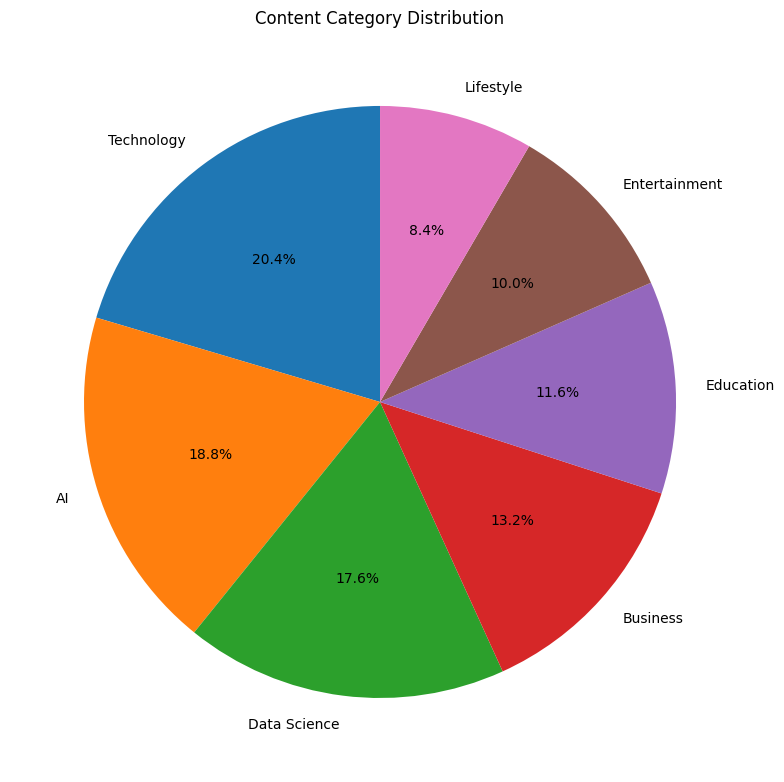

In [9]:
category_distribution = (
    df["Category"]
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    category_distribution.values,
    labels=category_distribution.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Content Category Distribution")

plt.tight_layout()

plt.show()

In [10]:
positive_words = [
    "love", "loved", "amazing", "fantastic",
    "great", "happy", "excited", "wonderful",
    "excellent", "inspiring", "achievement"
]

negative_words = [
    "disappointing", "frustrating", "poor",
    "problems", "not happy", "improvement",
    "issues"
]


def analyze_sentiment(text):

    text = str(text).lower()

    positive_score = sum(
        word in text
        for word in positive_words
    )

    negative_score = sum(
        word in text
        for word in negative_words
    )

    if positive_score > negative_score:
        return "Positive"

    elif negative_score > positive_score:
        return "Negative"

    else:
        return "Neutral"


df["Sentiment"] = df["Content"].apply(
    analyze_sentiment
)

sentiment_distribution = (
    df["Sentiment"]
    .value_counts()
    .reset_index()
)

sentiment_distribution.columns = [
    "Sentiment",
    "Count"
]

print("😊 SENTIMENT ANALYSIS")
print(sentiment_distribution)

😊 SENTIMENT ANALYSIS
  Sentiment  Count
0  Positive    120
1   Neutral     89
2  Negative     41


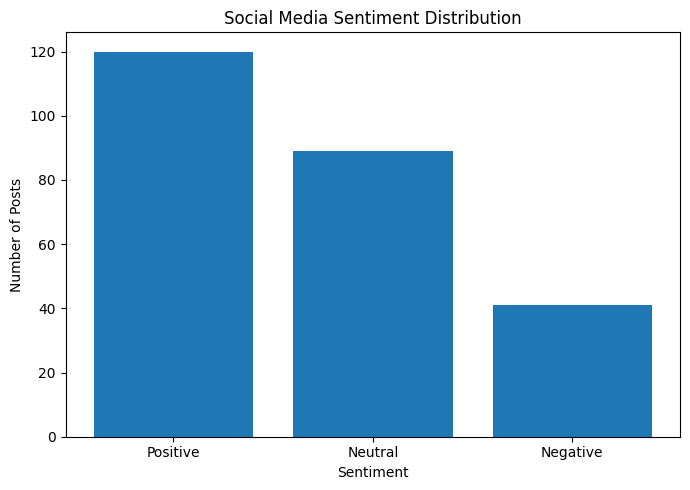

In [11]:
sentiment_counts = df["Sentiment"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Social Media Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")

plt.tight_layout()

plt.show()

In [12]:
top_hashtag_name = top_hashtags.iloc[0]["Hashtag"]
top_hashtag_count = top_hashtags.iloc[0]["Count"]

most_active_user = active_users.iloc[0]["User"]
most_active_user_posts = active_users.iloc[0]["Posts"]

popular_time = (
    f"{most_popular_hour:02d}:00 - "
    f"{(most_popular_hour + 1) % 24:02d}:00"
)

analytics_report = pd.DataFrame({
    "Metric": [
        "Total Posts",
        "Total Likes",
        "Total Comments",
        "Total Shares",
        "Total Engagement",
        "Average Engagement per Post",
        "Top Trending Hashtag",
        "Top Hashtag Count",
        "Most Active User",
        "Posts by Most Active User",
        "Most Popular Posting Time",
        "Positive Posts",
        "Neutral Posts",
        "Negative Posts"
    ],

    "Value": [
        len(df),
        total_likes,
        total_comments,
        total_shares,
        total_engagement,
        round(average_engagement, 2),
        top_hashtag_name,
        top_hashtag_count,
        most_active_user,
        most_active_user_posts,
        popular_time,
        sentiment_counts.get("Positive", 0),
        sentiment_counts.get("Neutral", 0),
        sentiment_counts.get("Negative", 0)
    ]
})

analytics_report

,Metric,Value
0,Total Posts,250
1,Total Likes,347013
2,Total Comments,44411
3,Total Shares,68265
4,Total Engagement,459689
5,Average Engagement per Post,1838.76
6,Top Trending Hashtag,#python
7,Top Hashtag Count,55
8,Most Active User,AIInsights
9,Posts by Most Active User,30


In [13]:
report_file = "social_media_analytics_report.csv"

analytics_report.to_csv(
    report_file,
    index=False
)

print(
    f"Report exported successfully as {report_file}"
)

files.download(report_file)

Report exported successfully as social_media_analytics_report.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>